# JCX Payin Lookup V1 — Day-Zero Historical Baseline

**Goal.** Build a $-weighted historical lookup of `payin_ratio_realized` by
`(DM_Band_Name, CM_Band_Name, CustType, PortFolioID, AppMonth, AppWeek, Frequency_group3)`
from matured loans, and apply it to the most recent 6 months of originations to produce
a stable day-zero projection per cohort week.

**Train / test split.**  `OriginationDate <= 2025-11-30` is the training (matured) set;
`OriginationDate > 2025-11-30` is the held-out test set we apply the lookup to.

**Output.** A weekly cohort projection plot — one panel per CustType (NEW / RETURN),
x-axis = `AppYear-AppWeek` of test cohorts, y-axis = projected final payin ratio from
the lookup.

No comparison against the model in this notebook — pure lookup baseline.

In [1]:
# Imports + paths (mirrors jcx_2026_projection_V5.ipynb)
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')

from util.db import create_db_engine
from util.sql_loader import read_sql_file
from util.sql_runner import execute_sql_and_read_temp_table
from util.plot_style import apply_plot_style, PRIMARY_COLOR, ACCENT_COLOR, PLOT_PALETTE
from util.payin_lookup import (
    assign_frequency_group3,
    compute_payin_ratio,
    build_lookup_table,
    apply_lookup,
    score_cohort,
)

project_root = Path.cwd().resolve().parent
env_path = project_root / '.env'
sql_path = project_root / 'sql_scripts' / 'jcx_payin_lookup_v1.sql'

engine = create_db_engine(env_path)
setup_sql = read_sql_file(sql_path)

lookup_df_raw = execute_sql_and_read_temp_table(engine, setup_sql, '#t_lookup')
print('SQL loaded from:', sql_path)
print('lookup_df_raw shape:', lookup_df_raw.shape)
lookup_df_raw.head()

SQL loaded from: /Users/starsrain/2025_concord/yieldCurve_augmenting/sql_scripts/jcx_payin_lookup_v1.sql
lookup_df_raw shape: (205177, 14)


,Application_ID,PortFolioID,LoanID,LoanStatus,CustType,AppYear,AppMonth,AppWeek,Frequency,DM_Band_Name,CM_Band_Name,OriginatedAmount,OriginationDate,TotalRealizedPayment
0,71456263,7,I1540910-0,D,RETURN,2023,1,2,S,DM05,CM08,1500.0,2023-01-13,3125.00
1,71456402,1,I1532745-0,D,RETURN,2023,1,1,B,DM04,CM07,600.0,2023-01-05,705.00
2,71456701,1,I1532749-0,D,RETURN,2023,1,1,B,DM06,CM07,1500.0,2023-01-05,3385.71
3,71458280,7,I1540971-0,D,RETURN,2023,1,2,B,DM05,CM06,500.0,2023-01-13,824.29
4,72747768,7,I1568507-0,D,NEW,2023,2,7,B,DM04,CM07,200.0,2023-02-14,450.00


## 1. Feature derivation
- `payin_ratio_realized = TotalRealizedPayment / OriginatedAmount`
- `Frequency_group3`: W stays W; B and S → B; M stays M.

In [2]:
df = lookup_df_raw.copy()

# Numeric / datetime coercion
df['OriginationDate'] = pd.to_datetime(df['OriginationDate'], errors='coerce')
for c in ['OriginatedAmount', 'TotalRealizedPayment', 'AppYear', 'AppMonth', 'AppWeek']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Required derived columns
df['payin_ratio_realized'] = compute_payin_ratio(df, 'TotalRealizedPayment', 'OriginatedAmount')
df['Frequency_group3'] = assign_frequency_group3(df['Frequency'])

# Categorical normalization (string + fillna)
for c in ['DM_Band_Name', 'CM_Band_Name', 'CustType']:
    df[c] = df[c].astype(str).str.strip().str.upper().replace({'NAN': 'UNKNOWN', '': 'UNKNOWN'}).fillna('UNKNOWN')

print('rows:', len(df))
print('unique loans:', df['LoanID'].nunique())
print('origination date min / max:', df['OriginationDate'].min(), '/', df['OriginationDate'].max())
print('\nNull / UNKNOWN rates on lookup keys:')
for c in ['DM_Band_Name', 'CM_Band_Name', 'CustType', 'PortFolioID', 'AppMonth', 'AppWeek', 'Frequency_group3']:
    if c in df.columns:
        unk = (df[c].astype(str).str.upper() == 'UNKNOWN').sum() if df[c].dtype == object else 0
        nulls = df[c].isna().sum()
        print(f'  {c:20s}  nulls={nulls:>7,}  UNKNOWN={unk:>7,}')

df.head()

rows: 205177
unique loans: 205177
origination date min / max: 2023-01-01 00:00:00 / 2026-06-03 00:00:00

Null / UNKNOWN rates on lookup keys:
  DM_Band_Name          nulls=      0  UNKNOWN=      0
  CM_Band_Name          nulls=      0  UNKNOWN=      0
  CustType              nulls=      0  UNKNOWN=      0
  PortFolioID           nulls=      0  UNKNOWN=      0
  AppMonth              nulls=      0  UNKNOWN=      0
  AppWeek               nulls=      0  UNKNOWN=      0
  Frequency_group3      nulls=      0  UNKNOWN=      5


,Application_ID,PortFolioID,LoanID,LoanStatus,CustType,AppYear,AppMonth,AppWeek,Frequency,DM_Band_Name,CM_Band_Name,OriginatedAmount,OriginationDate,TotalRealizedPayment,payin_ratio_realized,Frequency_group3
0,71456263,7,I1540910-0,D,RETURN,2023,1,2,S,DM05,CM08,1500.0,2023-01-13,3125.00,2.083333,B
1,71456402,1,I1532745-0,D,RETURN,2023,1,1,B,DM04,CM07,600.0,2023-01-05,705.00,1.175000,B
2,71456701,1,I1532749-0,D,RETURN,2023,1,1,B,DM06,CM07,1500.0,2023-01-05,3385.71,2.257140,B
3,71458280,7,I1540971-0,D,RETURN,2023,1,2,B,DM05,CM06,500.0,2023-01-13,824.29,1.648580,B
4,72747768,7,I1568507-0,D,NEW,2023,2,7,B,DM04,CM07,200.0,2023-02-14,450.00,2.250000,B


## 2. Train / test split — `OriginationDate <= 2025-11-30`
Today is 2026-05-20, so this gives a clean 6-month lag for maturity.

In [3]:
MATURITY_CUTOFF = pd.Timestamp('2025-11-30')

train_mask = df['OriginationDate'] <= MATURITY_CUTOFF
test_mask  = df['OriginationDate'] >  MATURITY_CUTOFF

train_df = df[train_mask].copy()
test_df  = df[test_mask].copy()

split_summary = pd.DataFrame({
    'set': ['train (matured)', 'test (recent)'],
    'n_loans': [len(train_df), len(test_df)],
    'orig_total': [train_df['OriginatedAmount'].sum(), test_df['OriginatedAmount'].sum()],
    'orig_min_date': [train_df['OriginationDate'].min(), test_df['OriginationDate'].min()],
    'orig_max_date': [train_df['OriginationDate'].max(), test_df['OriginationDate'].max()],
    'mean_payin_ratio': [
        np.average(train_df['payin_ratio_realized'], weights=train_df['OriginatedAmount'].fillna(0).clip(lower=0))
          if train_df['OriginatedAmount'].sum() > 0 else np.nan,
        np.average(test_df['payin_ratio_realized'], weights=test_df['OriginatedAmount'].fillna(0).clip(lower=0))
          if test_df['OriginatedAmount'].sum() > 0 else np.nan,
    ],
})
print(split_summary.to_string(index=False))

print('\nTrain payin_ratio_realized distribution (loan-level, $-unweighted):')
print(train_df['payin_ratio_realized'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(4))

            set  n_loans  orig_total orig_min_date orig_max_date  mean_payin_ratio
train (matured)   179056 140643985.0    2023-01-01    2025-11-30          1.628990
  test (recent)    26070  20373805.0    2025-12-01    2026-06-03          1.024024

Train payin_ratio_realized distribution (loan-level, $-unweighted):
count    179056.0000
mean          1.6432
std           1.2216
min           0.0000
5%            0.0000
25%           0.9000
50%           1.2833
75%           2.3556
95%           4.0450
max           8.6000
Name: payin_ratio_realized, dtype: float64


## 3. Build the lookup table with fallback hierarchy

Primary keys (most specific):
`(DM_Band_Name, CM_Band_Name, CustType, PortFolioID, AppMonth, AppWeek, Frequency_group3)`

Fallback drop order (most specific drop first):
1. drop `AppWeek` → coarsen to month
2. drop `AppMonth` → no seasonal
3. drop `CM_Band_Name`
4. drop `PortFolioID`
5. drop `Frequency_group3`
6. drop `DM_Band_Name` → CustType only

Then a global tier as the last resort.

`min_n = 50` per cell; cells thinner than that fall through to the next coarser tier.

In [4]:
PRIMARY_KEYS = [
    'DM_Band_Name', 'CM_Band_Name', 'CustType', 'PortFolioID',
    'AppMonth', 'AppWeek', 'Frequency_group3',
]
FALLBACK_DROP_ORDER = [
    'AppWeek',          # tier 1: drop week, keep month
    'AppMonth',         # tier 2: drop month entirely
    'CM_Band_Name',     # tier 3
    'PortFolioID',      # tier 4
    'Frequency_group3', # tier 5
    'DM_Band_Name',     # tier 6: CustType only
]
MIN_N = 50

lookup = build_lookup_table(
    train_df=train_df,
    primary_keys=PRIMARY_KEYS,
    fallback_drop_order=FALLBACK_DROP_ORDER,
    payin_col='payin_ratio_realized',
    orig_col='OriginatedAmount',
    min_n=MIN_N,
)

print('Lookup tier coverage:')
print(lookup.summary().to_string(index=False))
print('\nTier-0 (most specific) head:')
lookup.tiers[0].head(10)

Lookup tier coverage:
 tier                                                                                   keys  cells  loans_total
    0 DM_Band_Name, CM_Band_Name, CustType, PortFolioID, AppMonth, AppWeek, Frequency_group3     48         4912
    1          DM_Band_Name, CM_Band_Name, CustType, PortFolioID, AppMonth, Frequency_group3    779        62269
    2                    DM_Band_Name, CM_Band_Name, CustType, PortFolioID, Frequency_group3    681       165295
    3                                  DM_Band_Name, CustType, PortFolioID, Frequency_group3    187       178932
    4                                               DM_Band_Name, CustType, Frequency_group3     48       179050
    5                                                                 DM_Band_Name, CustType     16       179055
    6                                                                               CustType      2       179056
    7                                                                     

,DM_Band_Name,CM_Band_Name,CustType,PortFolioID,AppMonth,AppWeek,Frequency_group3,expected_payin,payin_std,n_loans,orig_total
0,NONE,NONE,NEW,1,4,17,B,1.314781,1.238780,90,59700.0
1,NONE,NONE,NEW,1,3,13,B,1.303186,1.275007,140,101650.0
2,NONE,NONE,NEW,1,5,20,B,1.459965,1.342321,118,75650.0
3,NONE,NONE,NEW,7,5,22,B,1.578917,1.438447,117,75100.0
4,NONE,NONE,NEW,6,5,20,B,1.438817,1.303821,98,61700.0
5,NONE,NONE,NEW,5,3,12,B,1.249759,1.234307,116,81550.0
6,NONE,NONE,NEW,5,3,10,B,1.315613,1.221069,103,72800.0
7,NONE,NONE,NEW,5,5,21,B,1.307282,1.272758,127,77050.0
8,NONE,NONE,NEW,5,5,19,B,1.512669,1.282014,140,88450.0
9,NONE,NONE,NEW,1,3,10,B,1.642097,1.328908,83,61850.0


## 4. Apply lookup to the test set

In [5]:
scored_test = apply_lookup(test_df, lookup)

print('Test loans scored:', len(scored_test))
print('Unmatched (no tier resolved):', scored_test['expected_payin'].isna().sum())
print('\nFallback tier usage on test:')
tier_use = (
    scored_test['lookup_tier']
    .value_counts(dropna=False)
    .rename_axis('tier')
    .reset_index(name='loans')
    .sort_values('tier')
)
tier_use['pct'] = (tier_use['loans'] / tier_use['loans'].sum()).round(4)
print(tier_use.to_string(index=False))

scored_test.head()

Test loans scored: 26070
Unmatched (no tier resolved): 0

Fallback tier usage on test:
 tier  loans    pct
  0.0   3493 0.1340
  1.0   7662 0.2939
  2.0  13500 0.5178
  3.0   1397 0.0536
  4.0     18 0.0007


,Application_ID,PortFolioID,LoanID,LoanStatus,CustType,AppYear,AppMonth,AppWeek,Frequency,DM_Band_Name,CM_Band_Name,OriginatedAmount,OriginationDate,TotalRealizedPayment,payin_ratio_realized,Frequency_group3,expected_payin,lookup_std,lookup_tier,lookup_n
254,108275333,1,I2507427-0,D,RETURN,2025,12,52,S,DM05,CM03,1500.0,2025-12-23,1600.0,1.066667,B,1.607831,1.016333,2.0,374.0
266,110324262,7,I2528189-0,N,RETURN,2026,1,4,B,DM04,CM05,1200.0,2026-01-20,3365.0,2.804167,B,1.699300,1.172665,2.0,450.0
269,110324891,7,I2528204-0,D,NEW,2026,1,4,M,DM01,CM06,600.0,2026-01-20,780.0,1.300000,M,1.135472,1.417466,3.0,151.0
281,107021714,1,I2483957-0,C,RETURN,2025,11,48,W,DM04,CM05,1500.0,2025-12-01,575.0,0.383333,W,1.621766,0.904770,2.0,156.0
295,107693908,1,I2496467-0,D,NEW,2025,12,50,W,DM06,CM06,900.0,2025-12-10,1962.0,2.180000,W,1.763824,1.131773,3.0,206.0


## 5. Cohort scoring by `(CustType, AppYear, AppWeek)`

In [6]:
cohort = score_cohort(
    scored_test,
    cohort_cols=['CustType', 'AppYear', 'AppWeek'],
    payin_pred_col='expected_payin',
    weight_col='OriginatedAmount',
    realized_col='payin_ratio_realized',
)
cohort['AppYear'] = pd.to_numeric(cohort['AppYear'], errors='coerce').astype('Int64')
cohort['AppWeek'] = pd.to_numeric(cohort['AppWeek'], errors='coerce').astype('Int64')
cohort = cohort.sort_values(['CustType', 'AppYear', 'AppWeek']).reset_index(drop=True)
cohort['week_label'] = (
    cohort['AppYear'].astype(str) + '-W' + cohort['AppWeek'].astype(str).str.zfill(2)
)

print('Cohort rows:', len(cohort))
cohort.head(20)

Cohort rows: 58


,CustType,AppYear,AppWeek,n_loans,orig_total,projected_payin,realized_payin,pct_unmatched,mean_tier,max_tier,week_label
0,NEW,2025,48,11,6900.0,1.514572,1.635394,0.0,1.636364,3.0,2025-W48
1,NEW,2025,49,380,259450.0,1.523116,1.417374,0.0,1.781579,3.0,2025-W49
2,NEW,2025,50,450,304150.0,1.541662,1.443360,0.0,1.871111,3.0,2025-W50
3,NEW,2025,51,504,335000.0,1.537147,1.553419,0.0,1.890873,3.0,2025-W51
4,NEW,2025,52,331,216450.0,1.521669,1.481203,0.0,1.824773,3.0,2025-W52
5,NEW,2025,53,271,183800.0,1.526992,1.397340,0.0,1.870849,3.0,2025-W53
6,NEW,2026,1,156,102000.0,1.600776,1.475298,0.0,1.814103,3.0,2026-W01
7,NEW,2026,2,508,336700.0,1.630068,1.359160,0.0,1.809055,3.0,2026-W02
8,NEW,2026,3,430,269450.0,1.564253,1.254246,0.0,1.939535,3.0,2026-W03
9,NEW,2026,4,451,287850.0,1.528437,1.277206,0.0,1.902439,3.0,2026-W04


## 6. Visualization — projected payin per cohort week, NEW vs RETURN
Mirrors the existing `apply_plot_style` look (muted blue / orange palette).

- Bars = realized to date (where it exists for the test cohort).
- Orange line = projected final payin from the lookup.
- Label above each point shows the lookup projection value.

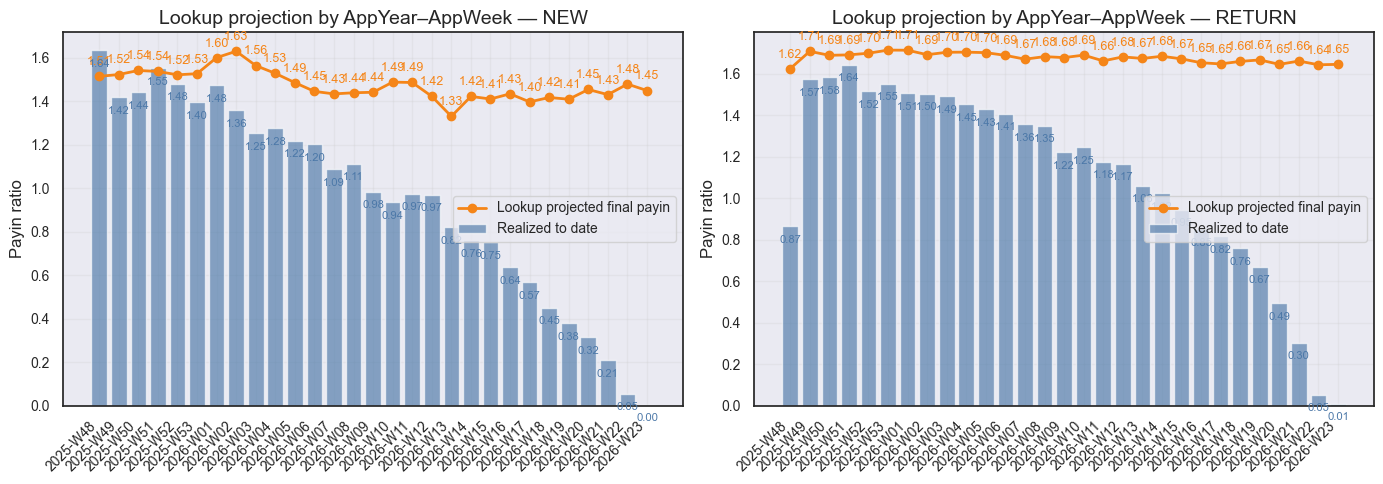

In [7]:
apply_plot_style(style='white', axes_grid=False)

cust_types = [ct for ct in ['NEW', 'RETURN'] if ct in cohort['CustType'].unique()]
n_panels = len(cust_types)
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5), sharey=False)
if n_panels == 1:
    axes = [axes]

for ax, ct in zip(axes, cust_types):
    sub = cohort[cohort['CustType'] == ct].copy()
    if sub.empty:
        ax.set_title(f'No test cohorts for CustType={ct}')
        continue

    x = np.arange(len(sub))
    realized = sub['realized_payin'].fillna(0.0).to_numpy()
    projected = sub['projected_payin'].to_numpy()

    ax.bar(x, realized, color=PRIMARY_COLOR, alpha=0.65, label='Realized to date')
    ax.plot(x, projected, 'o-', color=ACCENT_COLOR, linewidth=2, markersize=6,
            label='Lookup projected final payin')

    for xi, yp, yr in zip(x, projected, realized):
        if not np.isnan(yp):
            ax.annotate(f'{yp:.2f}', (xi, yp), textcoords='offset points',
                        xytext=(0, 8), ha='center', color=ACCENT_COLOR, fontsize=9)
        if yr > 0:
            ax.annotate(f'{yr:.2f}', (xi, yr), textcoords='offset points',
                        xytext=(0, -12), ha='center', color=PRIMARY_COLOR, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['week_label'], rotation=45, ha='right')
    ax.set_ylabel('Payin ratio')
    ax.set_title(f'Lookup projection by AppYear–AppWeek — {ct}')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

## 7. Fallback-tier diagnostic by cohort
Quick QC — high `mean_tier` on a cohort means most loans fell through to coarser fallbacks,
i.e., the lookup didn't have enough matched history at the full primary-key grain.

In [8]:
tier_qc = cohort[['CustType', 'week_label', 'n_loans', 'projected_payin',
                  'pct_unmatched', 'mean_tier', 'max_tier']].copy()
tier_qc['projected_payin'] = tier_qc['projected_payin'].round(4)
tier_qc['pct_unmatched'] = tier_qc['pct_unmatched'].round(4)
tier_qc['mean_tier'] = tier_qc['mean_tier'].round(2)
tier_qc

,CustType,week_label,n_loans,projected_payin,pct_unmatched,mean_tier,max_tier
0,NEW,2025-W48,11,1.5146,0.0,1.64,3.0
1,NEW,2025-W49,380,1.5231,0.0,1.78,3.0
2,NEW,2025-W50,450,1.5417,0.0,1.87,3.0
3,NEW,2025-W51,504,1.5371,0.0,1.89,3.0
4,NEW,2025-W52,331,1.5217,0.0,1.82,3.0
5,NEW,2025-W53,271,1.5270,0.0,1.87,3.0
6,NEW,2026-W01,156,1.6008,0.0,1.81,3.0
7,NEW,2026-W02,508,1.6301,0.0,1.81,3.0
8,NEW,2026-W03,430,1.5643,0.0,1.94,3.0
9,NEW,2026-W04,451,1.5284,0.0,1.90,3.0
